In [58]:
import pandas as pd

#### Get the flood dataset

In [ ]:
flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
5083,1001,2000,ALABAMA,AUTAUGA,1,200000.0,3.50
5084,1001,2001,ALABAMA,AUTAUGA,2,37000.0,4.25
5085,1001,2003,ALABAMA,AUTAUGA,2,58000.0,6.00
5086,1001,2004,ALABAMA,AUTAUGA,1,8000.0,3.50
0,1001,2005,ALABAMA,AUTAUGA,3,0.0,71.00
...,...,...,...,...,...,...,...
38743,56045,2012,WYOMING,WESTON,1,5000.0,1.00
38744,56045,2013,WYOMING,WESTON,3,135000.0,8.33
38745,56045,2015,WYOMING,WESTON,4,30000.0,37.08
38746,56045,2018,WYOMING,WESTON,1,0.0,40.08


#### Get the HPI dataset

In [ ]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()

,cbsa_code,cbsa_title,county_fips5,county/county_equivalent,state_name,place_name,place_id,yr,index_nsa,index_prev,hpi_change,hpi_yoy
13755,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2000,114.6775,113.7350,0.9425,0.828681
13756,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2001,119.9250,114.6775,5.2475,4.575876
13757,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2002,122.0075,119.9250,2.0825,1.736502
13758,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2003,125.8200,122.0075,3.8125,3.124808
13759,33860,"Montgomery, AL",1001,Autauga County,Alabama,"Montgomery, AL",33860,2004,129.5400,125.8200,3.7200,2.956605
...,...,...,...,...,...,...,...,...,...,...,...,...
3124,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2016,273.0800,278.0150,-4.9350,-1.775084
3125,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2017,269.6775,273.0800,-3.4025,-1.245972
3126,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2018,273.1500,269.6775,3.4725,1.287649
3127,16220,"Casper, WY",56025,Natrona County,Wyoming,"Casper, WY",16220,2019,280.6300,273.1500,7.4800,2.738422


#### Merge flood and HPI datasets

In [ ]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="inner",
)
hpi_flood  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20
...,...,...,...,...,...,...,...,...,...,...
14265,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50
14266,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00
14267,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00
14268,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83


#### Get heat dataset

In [110]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [ ]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [ ]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


#### Merge heat and HPI/flood datasets

In [ ]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["FIPS", "YEAR"],
    right_on=["FIPS", "year"],
    how="inner",
)
hpi_flood_heat  # .sort_values(by=["FIPS", "YEAR"])

,county_fips5,yr,hpi_yoy,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,year,value,heat_index,HSI
0,48059,2002,2.850440,48059,2002,TEXAS,CALLAHAN,2,807000.0,14.08,2002,90.8,0.059089,0.323792
1,48059,2003,2.620052,48059,2003,TEXAS,CALLAHAN,2,0.0,2.00,2003,92.8,0.178862,0.442478
2,48059,2004,4.455241,48059,2004,TEXAS,CALLAHAN,4,100000.0,4.18,2004,89.6,-0.000561,0.413233
3,48059,2005,6.922266,48059,2005,TEXAS,CALLAHAN,2,50000.0,4.02,2005,91.3,0.098956,0.344927
4,48059,2007,6.076846,48059,2007,TEXAS,CALLAHAN,6,2000.0,13.20,2007,87.9,-0.029850,0.220479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14223,4027,2014,3.042566,4027,2014,ARIZONA,YUMA,3,0.0,8.50,2014,105.0,0.336505,0.863331
14224,4027,2015,4.932343,4027,2015,ARIZONA,YUMA,4,100000.0,3.00,2015,105.8,0.383922,0.838107
14225,4027,2016,3.794342,4027,2016,ARIZONA,YUMA,3,0.0,3.00,2016,106.9,0.414770,0.872492
14226,4027,2018,3.642268,4027,2018,ARIZONA,YUMA,7,65000.0,17.83,2018,106.4,0.402691,0.818690


#### Get the drought and wildfire datasets

In [ ]:
hpi_flood_heat.to_csv(
    "../../02_processed_data/hpi_flood_heat_county_2000.csv", index=False
)

In [ ]:
for_training = hpi_flood[
    [
        "FIPS",
        "hpi_yoy",
        "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
    ]
]
Y = for_training["hpi_yoy"]
X = for_training.drop(columns=["hpi_yoy"])  # ,"FIPS","YEAR"

In [108]:
from scipy.stats import pearsonr
import statsmodels.formula.api as smf

r, p = pearsonr(for_training["COUNT"], for_training["hpi_yoy"])
print(f"Pearson correlation (COUNT vs HPI YoY): r={r:.3f}, p={p:.4g}")
r, p = pearsonr(for_training["TOTAL_DAMAGE_PROPERTY"], for_training["hpi_yoy"])
print(f"Pearson correlation (TOTAL DAMAGE PROPERTY vs HPI YoY): r={r:.3f}, p={p:.4g}")
r, p = pearsonr(for_training["TOTAL_DURATION_HOURS"], for_training["hpi_yoy"])
print(f"Pearson correlation (TOTAL DURATION HOURS vs HPI YoY): r={r:.3f}, p={p:.4g}")

# # --- Panel Regression (time FE) ---
# # Model: HPI YoY ~ Risk Score + Year Fixed Effects
# model = smf.ols("hpi_yoy ~ COUNT + C(YEAR)", data=for_training).fit(
#     cov_type="cluster" , cov_kwds={"groups": for_training["FIPS"]}
# )

# print(model.summary().tables[1])  # coefficients table

Pearson correlation (COUNT vs HPI YoY): r=-0.031, p=0.0002492
Pearson correlation (TOTAL DAMAGE PROPERTY vs HPI YoY): r=-0.001, p=0.8665
Pearson correlation (TOTAL DURATION HOURS vs HPI YoY): r=-0.020, p=0.01952


In [104]:
corr = X.corr(numeric_only=True)
print(corr)

                           FIPS      YEAR     COUNT  TOTAL_DAMAGE_PROPERTY  \
FIPS                   1.000000 -0.000573 -0.027433               0.020179   
YEAR                  -0.000573  1.000000  0.074920               0.028679   
COUNT                 -0.027433  0.074920  1.000000               0.019002   
TOTAL_DAMAGE_PROPERTY  0.020179  0.028679  0.019002               1.000000   
TOTAL_DURATION_HOURS  -0.035507  0.053217  0.092874               0.019114   

                       TOTAL_DURATION_HOURS  
FIPS                              -0.035507  
YEAR                               0.053217  
COUNT                              0.092874  
TOTAL_DAMAGE_PROPERTY              0.019114  
TOTAL_DURATION_HOURS               1.000000  


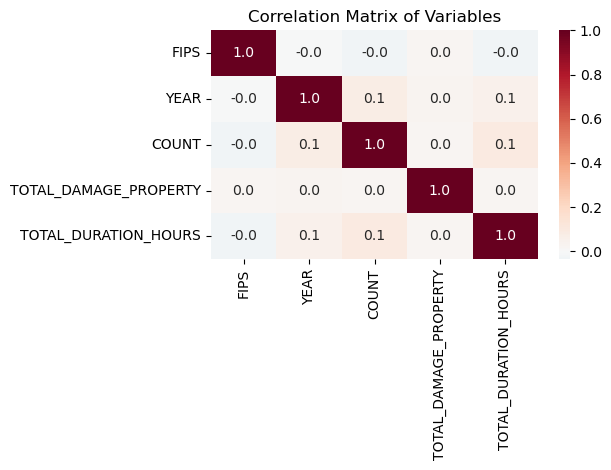

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()